# Exercise 4B

In this exercise, you will learn how to use PCA for dimensionality reduction to visualize clusters and then run a clustering algorithm.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
from sklearn.datasets import load_breast_cancer
df = load_breast_cancer(as_frame=True).frame

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
X = df.drop('target', axis=1)

1. Perform scaling `(10 pts)`

In [10]:
## put your answer here
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled


array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [9]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


2. Perform dimensionality reduction using PCA `(10 pts)`

In [12]:
## put your answer here
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)
X_reduced

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

In [14]:
X_reduced_df = pd.DataFrame(X_reduced)
X_reduced_df.head()

,0,1
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


3. Get the total explained variance `(5 pts)`

In [15]:
## put your answer here
explained_variance = pca.explained_variance_ratio_

PC1_explainedvariance = explained_variance[0]
print("Explained variance of PC1", PC1_explainedvariance)

PC2_explainedvariance = explained_variance[1]
print("Explained variance of PC2", PC2_explainedvariance)

Explained variance of PC1 0.44272025607526366
Explained variance of PC2 0.18971182044033078


4. Plot the explained variances of each principal component `(5 pts)`

In [16]:
## put your answer here
print("Total explained variance:", explained_variance.sum())

Total explained variance: 0.6324320765155944


5. Visualize the dataset after PCA using a scatter plot `(5 pts)`

Text(0.5, 1.0, 'Explained Variance of Each Principal Component')

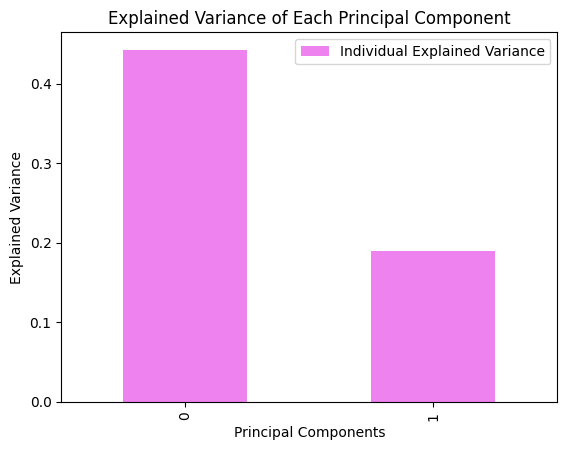

In [20]:
pd.DataFrame(explained_variance).plot.bar(color='violet')
plt.legend(['Individual Explained Variance'])
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance')
plt.title('Explained Variance of Each Principal Component')

6. Perform clustering using any clustering algorithm `(10 pts)`

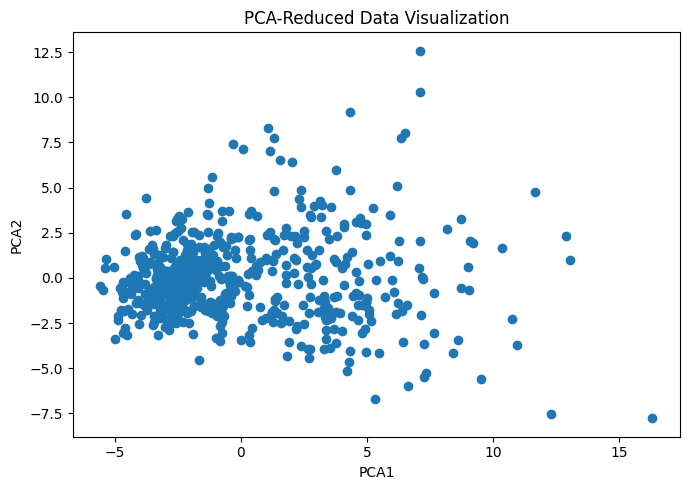

In [21]:
plt.figure(figsize=(7,5))

# Scatter plot
plt.scatter(X_reduced[:,0],X_reduced[:,1])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('PCA-Reduced Data Visualization')
plt.tight_layout()

7. View the loading scores of each principal component `(5 pts)`

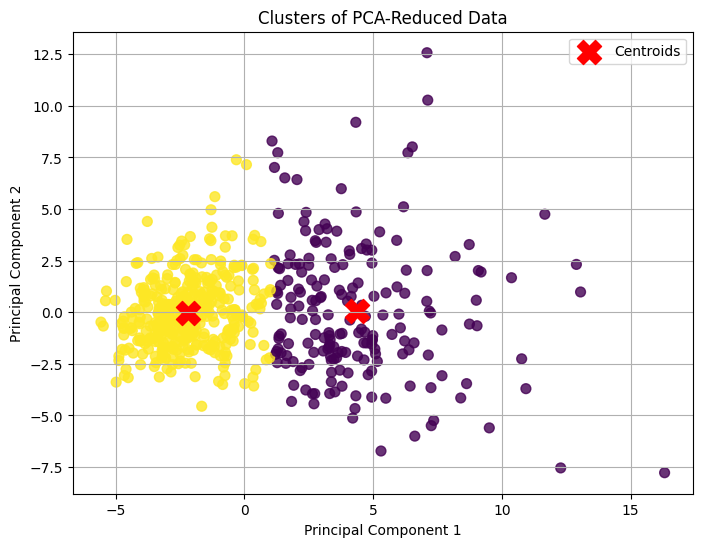

In [22]:
## put your answer here
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_reduced)

plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('Clusters of PCA-Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

I've used KMeans with 2 clusters, which is appropriate since the original Breast Cancer dataset has two target classes (malignant and benign). The plot shows the two clusters found by KMeans, along with their centroids.

In [23]:
loading_scores = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_scores_df = pd.DataFrame(loading_scores, index=X.columns, columns=['PC1', 'PC2'])
print(loading_scores_df)

                              PC1       PC2
mean radius              0.798469 -0.558394
mean texture             0.378346 -0.142564
mean perimeter           0.829965 -0.513800
mean area                0.806101 -0.551755
mean smoothness          0.520110  0.444392
mean compactness         0.872817  0.362680
mean concavity           0.942542  0.143660
mean concave points      0.951490 -0.083016
mean symmetry            0.503978  0.454506
mean fractal dimension   0.234772  0.875292
radius error             0.751328 -0.252033
texture error            0.063570  0.214849
perimeter error          0.770833 -0.213602
area error               0.739987 -0.363638
smoothness error         0.053005  0.488130
compactness error        0.621527  0.555669
concavity error          0.560234  0.470883
concave points error     0.669033  0.311176
symmetry error           0.155017  0.438984
fractal dimension error  0.374128  0.668791
worst radius             0.831641 -0.524987
worst texture            0.38106